# ML Pipeline 101: Complete Machine Learning Workflow

**Learn the entire process: Data → Model → Evaluation → Deployment**

In this tutorial, we'll build a complete ML pipeline from scratch using the Iris dataset.

## Step 0: Import Libraries

First, let's get all our tools ready:

In [16]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Model persistence
import pickle

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## Step 1: Load & Explore Data

The first step is always to understand your data.

In [3]:
# Load the data
df = pd.read_csv('iris_dataset.csv')

# Display basic info
print("📊 DATASET OVERVIEW")
print("="*50)
print(f"Shape: {df.shape} (rows, columns)")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\n📋 DATA TYPES:")
print(df.dtypes)

print(f"\n❓ MISSING VALUES:")
print(df.isnull().sum())

print(f"\n📈 BASIC STATISTICS:")
print(df.describe())

📊 DATASET OVERVIEW
Shape: (150, 5) (rows, columns)

First 5 rows:
   Sepal_Length_cm  Sepal_Width_cm  Petal_Length_cm  Petal_Width_cm Species
0              5.1             3.5              1.4             0.2  setosa
1              4.9             3.0              1.4             0.2  setosa
2              4.7             3.2              1.3             0.2  setosa
3              4.6             3.1              1.5             0.2  setosa
4              5.0             3.6              1.4             0.2  setosa

📋 DATA TYPES:
Sepal_Length_cm    float64
Sepal_Width_cm     float64
Petal_Length_cm    float64
Petal_Width_cm     float64
Species                str
dtype: object

❓ MISSING VALUES:
Sepal_Length_cm    0
Sepal_Width_cm     0
Petal_Length_cm    0
Petal_Width_cm     0
Species            0
dtype: int64

📈 BASIC STATISTICS:
       Sepal_Length_cm  Sepal_Width_cm  Petal_Length_cm  Petal_Width_cm
count       150.000000      150.000000       150.000000      150.000000
mean        

---
## Step 2: Exploratory Data Analysis (EDA)

Visualize to understand patterns:

In [4]:
# Check target distribution
print("🎯 TARGET DISTRIBUTION:")
print(df['Species'].value_counts())
print(f"\nBalanced? {df['Species'].value_counts().min() == df['Species'].value_counts().max()}")

🎯 TARGET DISTRIBUTION:
Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Balanced? True


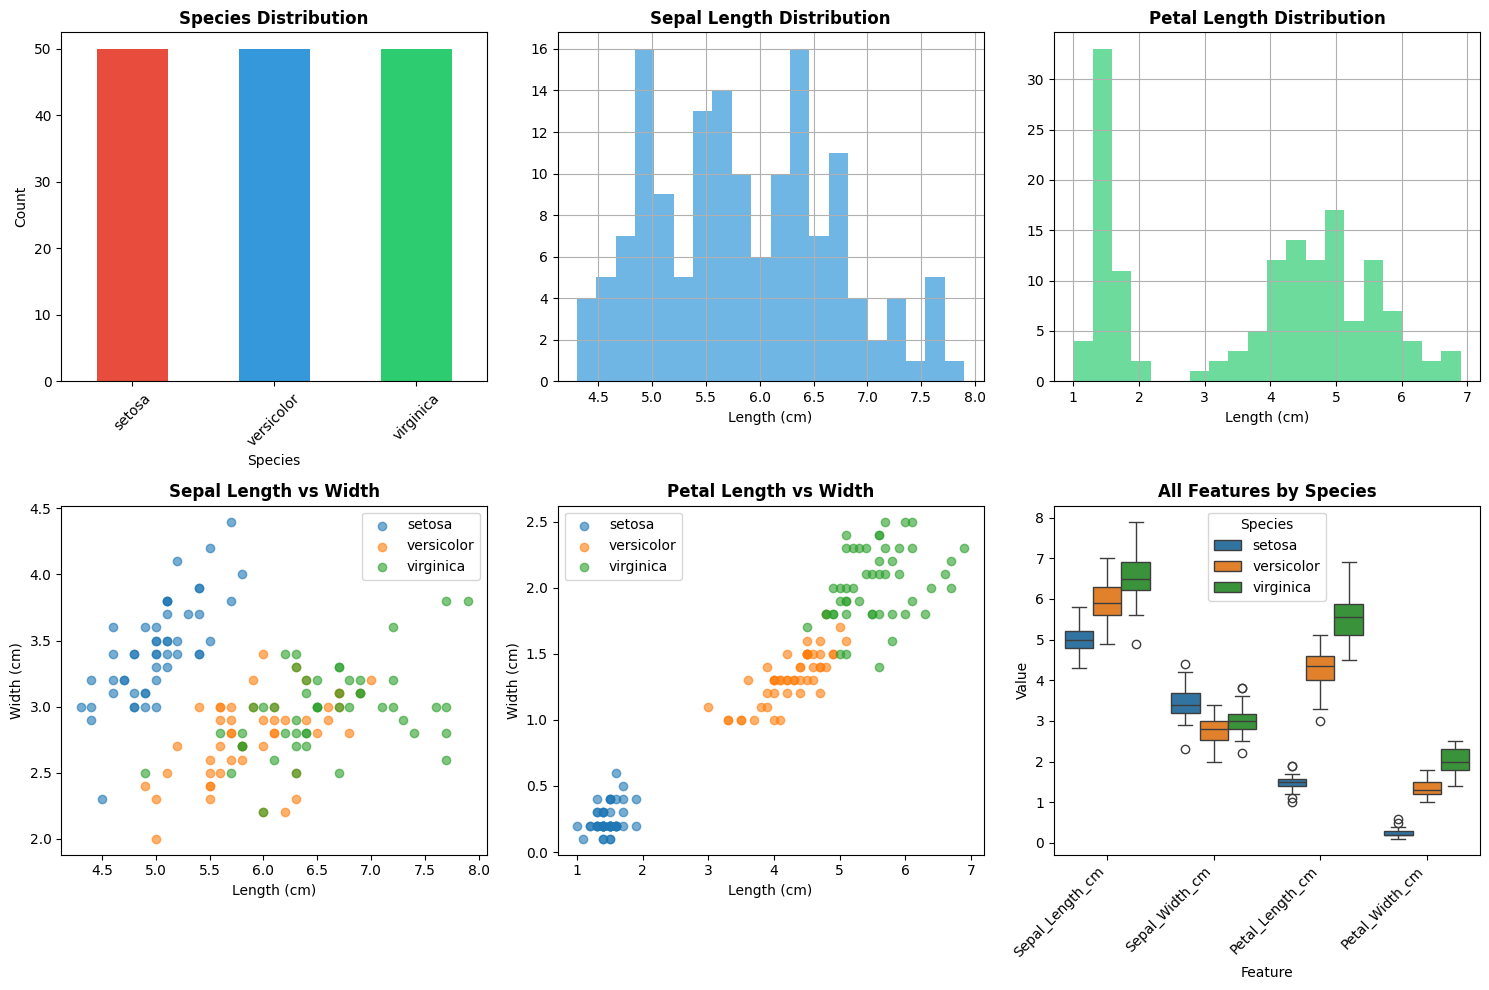

✅ Data visualized!


In [5]:
# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Species distribution
df['Species'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['#e74c3c', '#3498db', '#2ecc71'])
axes[0, 0].set_title('Species Distribution', fontweight='bold')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45)

# 2. Sepal Length distribution
df['Sepal_Length_cm'].hist(bins=20, ax=axes[0, 1], color='#3498db', alpha=0.7)
axes[0, 1].set_title('Sepal Length Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Length (cm)')

# 3. Petal Length distribution
df['Petal_Length_cm'].hist(bins=20, ax=axes[0, 2], color='#2ecc71', alpha=0.7)
axes[0, 2].set_title('Petal Length Distribution', fontweight='bold')
axes[0, 2].set_xlabel('Length (cm)')

# 4. Sepal Length vs Width (colored by species)
for species in df['Species'].unique():
    subset = df[df['Species'] == species]
    axes[1, 0].scatter(subset['Sepal_Length_cm'], subset['Sepal_Width_cm'], label=species, alpha=0.6)
axes[1, 0].set_title('Sepal Length vs Width', fontweight='bold')
axes[1, 0].set_xlabel('Length (cm)')
axes[1, 0].set_ylabel('Width (cm)')
axes[1, 0].legend()

# 5. Petal Length vs Width (colored by species)
for species in df['Species'].unique():
    subset = df[df['Species'] == species]
    axes[1, 1].scatter(subset['Petal_Length_cm'], subset['Petal_Width_cm'], label=species, alpha=0.6)
axes[1, 1].set_title('Petal Length vs Width', fontweight='bold')
axes[1, 1].set_xlabel('Length (cm)')
axes[1, 1].set_ylabel('Width (cm)')
axes[1, 1].legend()

# 6. Box plot of all features by species
df_melted = df.melt(id_vars='Species', var_name='Feature', value_name='Value')
sns.boxplot(data=df_melted, x='Feature', y='Value', hue='Species', ax=axes[1, 2])
axes[1, 2].set_title('All Features by Species', fontweight='bold')
axes[1, 2].set_xticklabels(axes[1, 2].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("✅ Data visualized!")

---
## Step 3: Data Preprocessing

Prepare data for the model:

In [6]:
# Separate features (X) and target (y)
X = df.drop('Species', axis=1)  # Features (all columns except Species)
y = df['Species']                # Target (what we're predicting)

print("📊 DATA SEPARATION")
print("="*50)
print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"\nFeatures: {X.columns.tolist()}")
print(f"Target Classes: {y.unique().tolist()}")

📊 DATA SEPARATION
Features (X): (150, 4)
Target (y): (150,)

Features: ['Sepal_Length_cm', 'Sepal_Width_cm', 'Petal_Length_cm', 'Petal_Width_cm']
Target Classes: ['setosa', 'versicolor', 'virginica']


In [7]:
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3,      # 30% for testing
    random_state=42,    # For reproducibility
    stratify=y          # Maintain class distribution
)

print("🔀 TRAIN-TEST SPLIT")
print("="*50)
print(f"Training set: {X_train.shape[0]} samples (70%)")
print(f"Testing set: {X_test.shape[0]} samples (30%)")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTesting set class distribution:")
print(y_test.value_counts())

🔀 TRAIN-TEST SPLIT
Training set: 105 samples (70%)
Testing set: 45 samples (30%)

Training set class distribution:
Species
versicolor    35
setosa        35
virginica     35
Name: count, dtype: int64

Testing set class distribution:
Species
virginica     15
versicolor    15
setosa        15
Name: count, dtype: int64


In [8]:
# Scale features (important for some models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Use same scaler as training

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("📏 FEATURE SCALING")
print("="*50)
print("Before scaling:")
print(X_train.describe())
print("\nAfter scaling:")
print(X_train_scaled.describe())

📏 FEATURE SCALING
Before scaling:
       Sepal_Length_cm  Sepal_Width_cm  Petal_Length_cm  Petal_Width_cm
count       105.000000      105.000000       105.000000      105.000000
mean          5.873333        3.055238         3.784762        1.205714
std           0.862941        0.457203         1.784052        0.777549
min           4.300000        2.000000         1.100000        0.100000
25%           5.100000        2.800000         1.600000        0.300000
50%           5.800000        3.000000         4.200000        1.300000
75%           6.400000        3.300000         5.100000        1.900000
max           7.900000        4.400000         6.900000        2.500000

After scaling:
       Sepal_Length_cm  Sepal_Width_cm  Petal_Length_cm  Petal_Width_cm
count     1.050000e+02    1.050000e+02     1.050000e+02    1.050000e+02
mean      3.002889e-16   -1.111016e-15    -1.395709e-16   -5.286776e-17
std       1.004796e+00    1.004796e+00     1.004796e+00    1.004796e+00
min      -1.83

---
## Step 4: Train Multiple Models

Compare 3 different algorithms:

In [9]:
# Model 1: Logistic Regression (Baseline)
print("🔵 MODEL 1: LOGISTIC REGRESSION")
print("="*50)
model_lr = LogisticRegression(random_state=42, max_iter=200)
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy: {accuracy_lr*100:.2f}%")
print("✅ Logistic Regression trained!")

# Model 2: Decision Tree
print("\n🟢 MODEL 2: DECISION TREE")
print("="*50)
model_dt = DecisionTreeClassifier(random_state=42, max_depth=5)
model_dt.fit(X_train, y_train)  # No scaling needed for trees
y_pred_dt = model_dt.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy: {accuracy_dt*100:.2f}%")
print("✅ Decision Tree trained!")

# Model 3: Random Forest
print("\n🔴 MODEL 3: RANDOM FOREST")
print("="*50)
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {accuracy_rf*100:.2f}%")
print("✅ Random Forest trained!")

🔵 MODEL 1: LOGISTIC REGRESSION
Accuracy: 91.11%
✅ Logistic Regression trained!

🟢 MODEL 2: DECISION TREE
Accuracy: 93.33%
✅ Decision Tree trained!

🔴 MODEL 3: RANDOM FOREST
Accuracy: 88.89%
✅ Random Forest trained!


---
## Step 5: Model Evaluation

Evaluate using multiple metrics:

In [10]:
# Function to evaluate model
def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    print(f"\n{'='*50}")
    print(f"📊 {model_name.upper()} EVALUATION")
    print(f"{'='*50}")
    print(f"Accuracy:  {accuracy*100:6.2f}%")
    print(f"Precision: {precision*100:6.2f}%")
    print(f"Recall:    {recall*100:6.2f}%")
    print(f"F1-Score:  {f1*100:6.2f}%")
    
    print(f"\n📋 Confusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    
    return accuracy, precision, recall, f1

# Evaluate all models
results_lr = evaluate_model(y_test, y_pred_lr, "Logistic Regression")
results_dt = evaluate_model(y_test, y_pred_dt, "Decision Tree")
results_rf = evaluate_model(y_test, y_pred_rf, "Random Forest")


📊 LOGISTIC REGRESSION EVALUATION
Accuracy:   91.11%
Precision:  91.55%
Recall:     91.11%
F1-Score:   91.07%

📋 Confusion Matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]

📊 DECISION TREE EVALUATION
Accuracy:   93.33%
Precision:  94.44%
Recall:     93.33%
F1-Score:   93.27%

📋 Confusion Matrix:
[[15  0  0]
 [ 0 12  3]
 [ 0  0 15]]

📊 RANDOM FOREST EVALUATION
Accuracy:   88.89%
Precision:  89.81%
Recall:     88.89%
F1-Score:   88.78%

📋 Confusion Matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  4 11]]


In [11]:
# Compare models
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [results_lr[0]*100, results_dt[0]*100, results_rf[0]*100],
    'Precision': [results_lr[1]*100, results_dt[1]*100, results_rf[1]*100],
    'Recall': [results_lr[2]*100, results_dt[2]*100, results_rf[2]*100],
    'F1-Score': [results_lr[3]*100, results_dt[3]*100, results_rf[3]*100]
})

print("\n🏆 MODEL COMPARISON")
print("="*70)
print(comparison.to_string(index=False))

# Find best model
best_model_idx = comparison['Accuracy'].idxmax()
best_model_name = comparison.loc[best_model_idx, 'Model']
print(f"\n🥇 Best Model: {best_model_name}")


🏆 MODEL COMPARISON
              Model  Accuracy  Precision    Recall  F1-Score
Logistic Regression 91.111111  91.553544 91.111111 91.071429
      Decision Tree 93.333333  94.444444 93.333333 93.265993
      Random Forest 88.888889  89.814815 88.888889 88.776655

🥇 Best Model: Decision Tree


---
## Step 6: Detailed Classification Report

See performance per class:

In [12]:
# Detailed report for best model (Random Forest)
print("🔍 DETAILED CLASSIFICATION REPORT (RANDOM FOREST)")
print("="*60)
print(classification_report(y_test, y_pred_rf))

🔍 DETAILED CLASSIFICATION REPORT (RANDOM FOREST)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45



---
## Step 7: Feature Importance

Which features matter most?


⭐ FEATURE IMPORTANCE (RANDOM FOREST)
        Feature  Importance
 Petal_Width_cm    0.454769
Petal_Length_cm    0.401161
Sepal_Length_cm    0.121437
 Sepal_Width_cm    0.022633


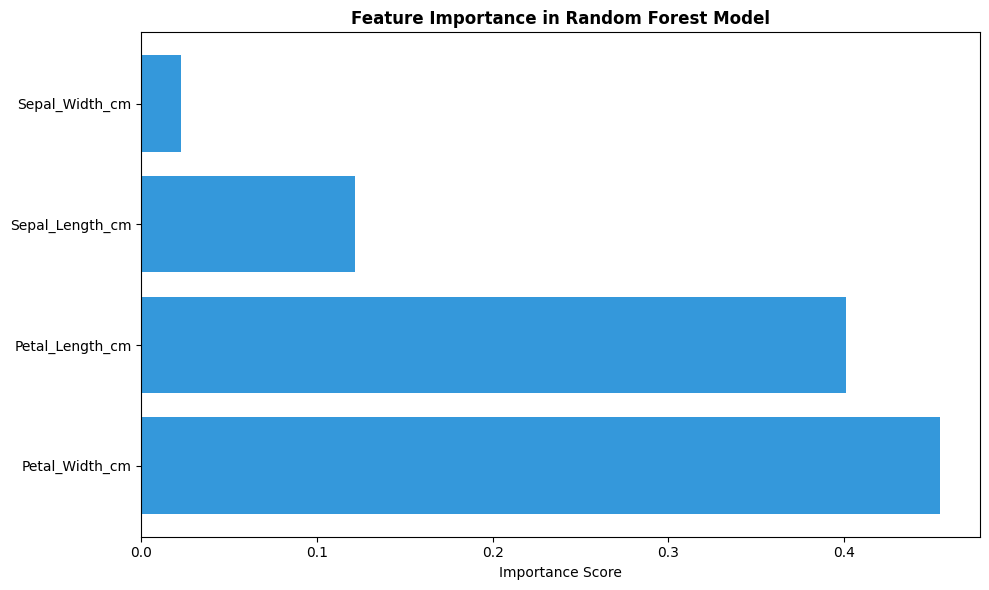

In [13]:
# Get feature importance from Random Forest
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n⭐ FEATURE IMPORTANCE (RANDOM FOREST)")
print("="*50)
print(importance.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance['Feature'], importance['Importance'], color='#3498db')
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance in Random Forest Model', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

---
## Step 8: Hyperparameter Tuning

Optimize the Random Forest model:

In [14]:
# Define parameter grid
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5]
}

# Grid Search
print("🔍 HYPERPARAMETER TUNING (Grid Search)")
print("="*50)
print(f"Testing {3*4*2} = 24 parameter combinations...\n")

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"✅ Best parameters: {grid_search.best_params_}")
print(f"✅ Best CV score: {grid_search.best_score_*100:.2f}%")

🔍 HYPERPARAMETER TUNING (Grid Search)
Testing 24 = 24 parameter combinations...

✅ Best parameters: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 10}
✅ Best CV score: 96.19%


In [15]:
# Test best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)

print("\n🏆 TUNED MODEL PERFORMANCE")
print("="*50)
print(f"Test Accuracy: {accuracy_best*100:.2f}%")
print(f"Improvement vs Original: {(accuracy_best - accuracy_rf)*100:+.2f}%")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred_best))


🏆 TUNED MODEL PERFORMANCE
Test Accuracy: 91.11%
Improvement vs Original: +2.22%

📋 Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



---
## Step 9: Save the Model

Deploy for production:

In [17]:
# Save the best model
with open('best_iris_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("✅ Model saved as 'best_iris_model.pkl'")

# Also save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
    
print("✅ Scaler saved as 'scaler.pkl'")

✅ Model saved as 'best_iris_model.pkl'
✅ Scaler saved as 'scaler.pkl'


In [18]:
# Load and use the model
with open('best_iris_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

print("✅ Model loaded successfully!")

# Make predictions on new data
new_samples = X_test.head(5)
predictions = loaded_model.predict(new_samples)

print("\n🔮 PREDICTIONS ON NEW DATA")
print("="*60)
print(f"\nSample measurements:")
print(new_samples.to_string())
print(f"\nPredictions:")
for i, (idx, pred) in enumerate(zip(new_samples.index, predictions)):
    print(f"  Sample {i+1}: {pred}")

✅ Model loaded successfully!

🔮 PREDICTIONS ON NEW DATA

Sample measurements:
     Sepal_Length_cm  Sepal_Width_cm  Petal_Length_cm  Petal_Width_cm
107              7.3             2.9              6.3             1.8
63               6.1             2.9              4.7             1.4
133              6.3             2.8              5.1             1.5
56               6.3             3.3              4.7             1.6
127              6.1             3.0              4.9             1.8

Predictions:
  Sample 1: virginica
  Sample 2: versicolor
  Sample 3: versicolor
  Sample 4: versicolor
  Sample 5: virginica


---
## Summary & Takeaways 🎓

### What We Covered

✅ **Step 1:** Load and explore data

✅ **Step 2:** Analyze patterns with visualization

✅ **Step 3:** Preprocess and scale data

✅ **Step 4:** Train 3 different models

✅ **Step 5:** Evaluate with multiple metrics

✅ **Step 6:** Analyze per-class performance

✅ **Step 7:** Identify important features

✅ **Step 8:** Tune hyperparameters for improvement

✅ **Step 9:** Save model for production

### Key Concepts

| Concept | Meaning | Why Important |
|---------|---------|---------------|
| Train-Test Split | 70% train, 30% test | Prevent overfitting |
| Scaling | Normalize feature ranges | Helps some models |
| Multiple Models | Compare 3+ algorithms | Find the best one |
| Evaluation Metrics | Accuracy, Precision, Recall, F1 | Measure performance properly |
| Feature Importance | Which features matter most | Understand decisions |
| Hyperparameter Tuning | Optimize model settings | Improve performance |

### Next Steps

1. **Try your own data** - Replace iris_dataset.csv with your data
2. **Experiment** - Change parameters and see what happens
3. **Learn more** - Deep learning, NLP, computer vision
4. **Build web app** - Deploy with Flask or Streamlit
5. **Production** - Handle real-world complexities

---

**Congratulations! You now understand the complete ML pipeline! 🚀**